In [1]:
from contabilidad.backend.storage.data_pipeline import DataPipeline, get_pipeline
import pandas as pd

In [2]:
pipeline = get_pipeline()

In [62]:
df_cuenta= pipeline.get_account_data()
inversiones=pipeline.pipeline.transformations[0]['func'](df_cuenta)

In [8]:
from contabilidad.backend.services.bank_parser.get_variables import get_credit_card_payments

min_banca_date = df_cuenta["FECHA"].min() if not df_cuenta.empty else None
pagos_tarjeta= get_credit_card_payments(df_cuenta)
# pagos_en_banca = [p for p in pagos_tarjeta if p.start_date and pd.to_datetime(p.start_date) >= min_banca_date]
# pagos_en_banca.sort(key=lambda x: pd.to_datetime(x.start_date))
# pagos_en_banca
pagos_tarjeta

[Payment(amount=np.float64(510.98), start_date='2024-03-18', end_date=None, description=None),
 Payment(amount=np.float64(510.98), start_date='2024-03-18', end_date=None, description=None),
 Payment(amount=np.float64(478.28), start_date='2024-06-20', end_date=None, description=None),
 Payment(amount=np.float64(20.0), start_date='2024-07-22', end_date=None, description=None),
 Payment(amount=np.float64(255.16), start_date='2024-08-06', end_date=None, description=None),
 Payment(amount=np.float64(20.0), start_date='2024-08-21', end_date=None, description=None),
 Payment(amount=np.float64(401.21), start_date='2024-09-20', end_date=None, description=None),
 Payment(amount=np.float64(45.11), start_date='2024-11-15', end_date=None, description=None),
 Payment(amount=np.float64(286.98), start_date='2024-11-19', end_date=None, description=None),
 Payment(amount=np.float64(20.0), start_date='2025-01-21', end_date=None, description=None),
 Payment(amount=np.float64(275.27), start_date='2025-01-2

In [21]:
df_consumos = pipeline.get_unified_credit_card_data()
df_consumos
col_consumo_fecha="FECHA"

df_metadata = pipeline.get_credit_card_metadata()
df_metadata

first_meta = df_metadata.iloc[0]
start_date = first_meta["FECHA_EMISION"]
df_consumos
col_consumo_valor = "MONTO"

In [4]:
from contabilidad.backend.services.bank_parser.get_variables import get_credit_card_payments, mark_fixed_payments
        
pagos_tarjeta = get_credit_card_payments(df_cuenta)
pagos_validos = [p for p in pagos_tarjeta]

temp_col_pagos = "PAGO_TARJETA"
df = mark_fixed_payments(df_cuenta, pagos_validos, temp_col_pagos, include_last=True)
df[temp_col_pagos] = df[temp_col_pagos].fillna(0)
df


,id,FECHA,DESCRIPCION,MONTO,FUENTE,SALDO,DEBITO,CREDITO,PAGO_TARJETA
0,4b4068d3a3207283a89ec772d66742fd,2024-03-11 00:00:00,TRANSFERENCIA INTERBANCARIA ENVIADA,-2.50,BANCO,31850.39,2.50,0.0,0.00
1,5f4499c5212ada7446102f6d5dcafd81,2024-03-11 00:00:00,TRANSFERENCIA INTERBANCARIA ENVIADA,-2.00,BANCO,31848.39,2.00,0.0,0.00
2,e0540c86de6217d17f20658eec31a3aa,2024-03-11 00:00:00,TRANSFERENCIA INTERNET,-9.00,BANCO,31839.39,9.00,0.0,0.00
3,a7df03655db99fff113f74128655ea18,2024-03-11 00:00:00,TRANSFERENCIA INTERBANCARIA ENVIADA,-16.00,BANCO,31823.39,16.00,0.0,0.00
4,52f5bf861287ed3f2c881048704be86f,2024-03-12 00:00:00,TRANSFERENCIA INTERBANCARIA ENVIADA,-3.99,BANCO,31819.40,3.99,0.0,0.00
...,...,...,...,...,...,...,...,...,...
868,8468ea5bc5a068d00647b5d2af2d3241,2026-03-09 09:36:00,TRANSF. DIRECTA A VILLACRES CARRILLO ALICIA,-2.00,BANCO,27786.67,2.00,0.0,6858.78
869,af4928787040450e04fb9c789d1df11c,2026-03-09 20:39:00,TRANSF. DEUNA A FABIOLA BERENICE TORRES GONZALEZ,-3.90,BANCO,27782.77,3.90,0.0,6858.78
870,27f40dbb3fd1da3a6b722e4d1344bc46,2026-03-09 14:33:00,TRANSF. DIRECTA A CHICHANDA LOOR BETTY FABIOLA,-3.00,BANCO,27779.77,3.00,0.0,6858.78
871,04e7f65c92dca06f2517ad5524dbb943,2026-03-10 14:19:00,TRANSF. DIRECTA A CHICHANDA LOOR BETTY FABIOLA,-4.00,BANCO,27775.77,4.00,0.0,6858.78


In [24]:
df_cuenta[df_cuenta["DESCRIPCION"].str.contains("MASTE")][["DESCRIPCION","FECHA","MONTO"]].iloc[-1]["DESCRIPCION"]

'PAGO TARJETA DE CREDITO MASTERCARD BANCO PICHINCHA  54660500045502'

In [5]:
pagos_tarjeta

[Payment(amount=np.float64(510.98), start_date='2024-03-18', end_date=None, description=None),
 Payment(amount=np.float64(510.98), start_date='2024-03-18', end_date=None, description=None),
 Payment(amount=np.float64(478.28), start_date='2024-06-20', end_date=None, description=None),
 Payment(amount=np.float64(20.0), start_date='2024-07-22', end_date=None, description=None),
 Payment(amount=np.float64(255.16), start_date='2024-08-06', end_date=None, description=None),
 Payment(amount=np.float64(20.0), start_date='2024-08-21', end_date=None, description=None),
 Payment(amount=np.float64(401.21), start_date='2024-09-20', end_date=None, description=None),
 Payment(amount=np.float64(45.11), start_date='2024-11-15', end_date=None, description=None),
 Payment(amount=np.float64(286.98), start_date='2024-11-19', end_date=None, description=None),
 Payment(amount=np.float64(20.0), start_date='2025-01-21', end_date=None, description=None),
 Payment(amount=np.float64(275.27), start_date='2025-01-2

<Axes: xlabel='FECHA'>

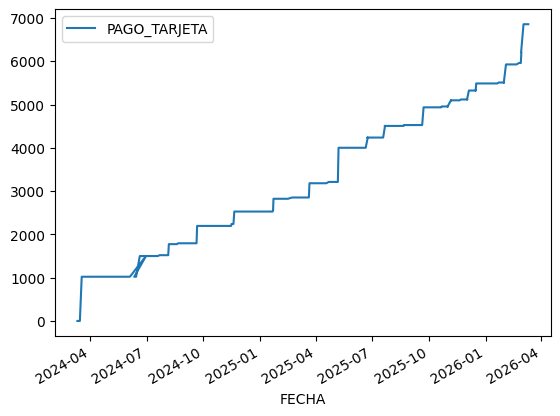

In [19]:
df.plot(x="FECHA",y="PAGO_TARJETA")

In [23]:
df_consumos_filtered = df_consumos[df_consumos[col_consumo_fecha] >= start_date].copy()

df_consumos_filtered = df_consumos_filtered.sort_values(col_consumo_fecha)
df_consumos_filtered['ACUMULADO_TARJETA'] = df_consumos_filtered[col_consumo_valor].cumsum()

df_consumos_filtered['ACUMULADO_TARJETA'] += 0

df_lookup = df_consumos_filtered[[col_consumo_fecha, 'ACUMULADO_TARJETA']].rename(columns={col_consumo_fecha: 'FECHA'})
 

In [8]:
df_lookup.plot(x="FECHA",y="ACUMULADO_TARJETA")

NameError: name 'df_lookup' is not defined

In [9]:
pagos_tarjeta

NameError: name 'pagos_tarjeta' is not defined

In [6]:
cards["ACUM"] = cards["MONTO"].cumsum()

<Axes: xlabel='FECHA'>

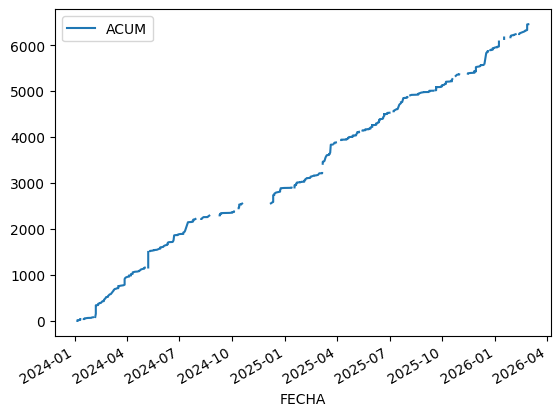

In [8]:
cards.plot(x="FECHA",y="ACUM")

In [6]:

from contabilidad.backend.storage.transformations.credit_cards import transform_credit_cards

In [7]:
df_unido=transform_credit_cards(df_cuenta)

Leyendo 25 archivos de tarjetas en /home/sebas/dev/projects/ContabilidadPersonal/data/sistema/procesada/tarjeta


In [ ]:
df_unido[]

,id,FECHA,DESCRIPCION,MONTO,FUENTE,SALDO,DEBITO,CREDITO,ACUMULADO_TARJETA,PAGO_TARJETA,TARJETA
0,NaN,2024-03-06 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,544.34,0.00,544.34
1,NaN,2024-03-08 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,581.57,0.00,581.57
2,NaN,2024-03-09 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,600.17,0.00,600.17
3,4b4068d3a3207283a89ec772d66742fd,2024-03-11 00:00:00,TRANSFERENCIA INTERBANCARIA ENVIADA,-2.5,BANCO,31850.39,2.5,0.0,622.56,0.00,622.56
4,e0540c86de6217d17f20658eec31a3aa,2024-03-11 00:00:00,TRANSFERENCIA INTERNET,-9.0,BANCO,31839.39,9.0,0.0,622.56,0.00,622.56
...,...,...,...,...,...,...,...,...,...,...,...
1103,8468ea5bc5a068d00647b5d2af2d3241,2026-03-09 09:36:00,TRANSF. DIRECTA A VILLACRES CARRILLO ALICIA,-2.0,BANCO,27786.67,2.0,0.0,6380.94,6211.78,169.16
1104,27f40dbb3fd1da3a6b722e4d1344bc46,2026-03-09 14:33:00,TRANSF. DIRECTA A CHICHANDA LOOR BETTY FABIOLA,-3.0,BANCO,27779.77,3.0,0.0,6380.94,6211.78,169.16
1105,af4928787040450e04fb9c789d1df11c,2026-03-09 20:39:00,TRANSF. DEUNA A FABIOLA BERENICE TORRES GONZALEZ,-3.9,BANCO,27782.77,3.9,0.0,6380.94,6211.78,169.16
1106,04e7f65c92dca06f2517ad5524dbb943,2026-03-10 14:19:00,TRANSF. DIRECTA A CHICHANDA LOOR BETTY FABIOLA,-4.0,BANCO,27775.77,4.0,0.0,6380.94,6211.78,169.16


In [32]:
df_unido[(df_unido["FUENTE"]!="BANCO")& (df_unido["MONTO"].notna())].query("FECHA > '2025-12-01' and FECHA < '2026-02-10'").head(30)[["FECHA","MONTO","ACUMULADO_TARJETA","PAGO_TARJETA","TARJETA"]]

,FECHA,MONTO,ACUMULADO_TARJETA,PAGO_TARJETA,TARJETA


<Axes: xlabel='FECHA'>

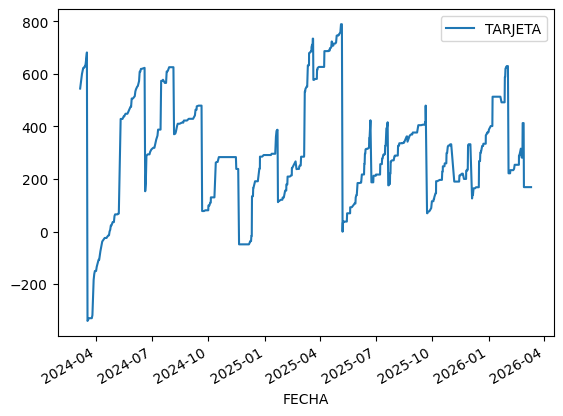

In [12]:
df_unido.plot(x="FECHA",y="TARJETA")

In [34]:
df_unido[(df_unido["FUENTE"]!="BANCO")& (df_unido["MONTO"].notna())]

,id,FECHA,DESCRIPCION,MONTO,FUENTE,SALDO,DEBITO,CREDITO,ACUMULADO_TARJETA,PAGO_TARJETA,TARJETA


## Proceced

In [64]:
df=pipeline.get_processed_data(source="tarjeta_unida")

In [65]:
df[df["FECHA"]>'2026-01-01']
# df[df["FUENTE"]!="BANCO"]
df.tail(30)

,id,FECHA,DESCRIPCION,MONTO,FUENTE,OPERACION,INVERSION,ACUMULADO_TARJETA,PAGO_TARJETA,TARJETA
637,023a751f2b4c999ef443c491e1150793,2026-01-27,Spotify P3EC5110AB S,6.99,TARJETA,CONSUMO,1398.6,6092.16,0.0,6092.16
638,80464599e1c65e0cdd103b750cb32b70,2026-01-27,RET IVA SERV DIGITAL 100%,1.05,TARJETA,N/D,1398.6,6092.16,0.0,6092.16
639,5f91fb114128f6632566356736eb605a,2026-01-28,TARIFA CONSUMO GASOLINERA,NaN,TARJETA,N/D T15,1367.0,6123.56,0.0,6123.56
640,90af8786a07a30ccdd67e7154c9699f4,2026-01-28,IVA,NaN,TARJETA,N/D IVA,1367.0,6123.56,0.0,6123.56
641,6052d6a39172bb0859d87ba076bf2c76,2026-01-28,AUTOSERVIPAMPA CIA. LT Q,31.40,TARJETA,CONSUMO,1367.0,6123.56,0.0,6123.56
642,43a7a229b479c250c8d3018380d79139,2026-01-29,FYBECA Q,5.50,TARJETA,CONSUMO,1367.0,6129.06,0.0,6129.06
643,45f2bb2f72622c12a510ef23280e9cc2,2026-01-30,RET IVA SERV DIGITAL 100%,0.60,TARJETA,N/D,1367.0,6133.65,0.0,6133.65
644,7a674a20f029b852098239b0c260bb06,2026-01-30,DLC*UBER RIDESRI S,3.99,TARJETA,CONSUMO,1367.0,6133.65,0.0,6133.65
645,c1d484593bfed2b74e24c23c63690734,2026-02-01,GOOGLE *CLOUD C4WGWF 6,0.01,TARJETA,CONSUMO,1367.0,6133.66,0.0,6133.66
646,da1591fc4e51c683b544b1c043e39b70,2026-02-02,UB *EATS ECUADOR 8,5.47,TARJETA,CONSUMO,1367.0,6143.98,0.0,6143.98


In [52]:
df

,id,FECHA,DESCRIPCION,MONTO,FUENTE,OPERACION,VALOR,INVERSION,ACUMULADO_TARJETA,PAGO_TARJETA,TARJETA
0,691181bf59add7034ede63ea41b766de,2024-01-06,MCDONALDS EC KSU G,-6.98,TARJETA,CONSUMO,6.98,26610.0,0.00,0.0,0.00
1,1c5fc02d06c9f4271f3eea699e78505e,2024-01-06,MEGAMAXI EL CONDADO LC Q,-13.62,TARJETA,CONSUMO,13.62,26610.0,0.00,0.0,0.00
2,511381a13bbeb848ddddf708ea854721,2024-01-06,PYCCA CONDADOECU Q,-3.19,TARJETA,CONSUMO,3.19,26610.0,0.00,0.0,0.00
3,3907fdbb2f82f617ed49123e00945b55,2024-01-08,GOOGLE *Google Storage 6,-1.99,TARJETA,CONSUMO,1.99,26610.0,0.00,0.0,0.00
4,824c9ba3e9237c615df39e8560a9bfec,2024-01-08,RET IVA SERV DIGITAL 100%,-0.24,TARJETA,N/D,0.24,26610.0,0.00,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...
662,f3a2cdb25ddcf4a3c58371eb03686166,2026-02-25,SUPERMAXI BICENTENARIO Q CONSUMO ECU,-39.57,TARJETA,NaN,39.57,29671.0,6369.04,0.0,6369.04
663,abfd332ed999f3f6f268a3ca13ffc6f6,2026-02-25,ZURITA Y ZURITA LABORA Q CONSUMO ECU,-9.50,TARJETA,NaN,9.50,29671.0,6369.04,0.0,6369.04
664,df949b360a42e0e1c9ec5e8adf540dea,2026-02-25,RET IVA SERV DIGITAL 10% N/D,-1.22,TARJETA,NaN,1.22,29671.0,6369.04,0.0,6369.04
665,701da005eb85706c6ca928e57d788a7b,2026-02-27,DLC*UBER RIDESCU S CONSUMO CRI,-3.99,TARJETA,NaN,3.99,29671.0,6373.63,0.0,6373.63


In [55]:
from contabilidad.backend.routes.dashboard import DashboardService

In [57]:
dashboard = DashboardService()
df= dashboard.get_chart_data()

In [58]:
df

DashboardResponse(data=[ChartDataPoint(date='2024-01-06', total=-27967.0, saldo=0.0, saldo_sin_inversion=-27967.0, tarjeta=0.0, pagos_fijos=27967.0, interpolado=0.0, notion=0.0, deuda_acumulada=0.0, diff_total=0.0, diff_tarjeta=0.0, diff_saldo_sin_inversion=0.0, diff_notion=0.0, diff_deuda_acumulada=0.0, diff_pagos_fijos=0.0, diff_interpolados=0.0), ChartDataPoint(date='2024-01-07', total=-27967.0, saldo=0.0, saldo_sin_inversion=-27967.0, tarjeta=0.0, pagos_fijos=27967.0, interpolado=0.0, notion=0.0, deuda_acumulada=0.0, diff_total=0.0, diff_tarjeta=0.0, diff_saldo_sin_inversion=0.0, diff_notion=0.0, diff_deuda_acumulada=0.0, diff_pagos_fijos=0.0, diff_interpolados=0.0), ChartDataPoint(date='2024-01-08', total=-27967.0, saldo=0.0, saldo_sin_inversion=-27967.0, tarjeta=0.0, pagos_fijos=27967.0, interpolado=0.0, notion=0.0, deuda_acumulada=0.0, diff_total=0.0, diff_tarjeta=0.0, diff_saldo_sin_inversion=0.0, diff_notion=0.0, diff_deuda_acumulada=0.0, diff_pagos_fijos=0.0, diff_interpolado

In [3]:
df= pipeline.get_processed_data()

/home/sebas/dev/projects/ContabilidadPersonal/contabilidad/backend/.venv/lib64/python3.14/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
/home/sebas/dev/projects/ContabilidadPersonal/contabilidad/backend/.venv/lib64/python3.14/site-packages/pandera/_pandas_deprecated.py:154: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libra

Leyendo 25 archivos de tarjetas en /home/sebas/dev/projects/ContabilidadPersonal/data/sistema/procesada/tarjeta
Index(['id', 'FECHA', 'DESCRIPCION', 'MONTO', 'FUENTE', 'SALDO', 'DEBITO',
       'CREDITO', 'INVERSION', 'OPERACION', 'VALOR', 'ACUMULADO_TARJETA',
       'PAGO_TARJETA', 'TARJETA', 'DEUDA_ACUMULADA', 'PAGOS_FIJOS',
       'INTERPOLADO'],
      dtype='str')


In [4]:
df

,id,FECHA,DESCRIPCION,MONTO,FUENTE,SALDO,DEBITO,CREDITO,INVERSION,OPERACION,...,PAGOS_FIJOS,INTERPOLADO,saldo_sin_inversion,TOTAL,diff_total,diff_tarjeta,diff_saldo_sin_inversion,diff_pagos_fijos,diff_interpolados,diff_deuda_acumulada
874,1c5fc02d06c9f4271f3eea699e78505e,2024-01-06 00:00:00,MEGAMAXI EL CONDADO LC Q,-13.62,TARJETA,0.00,NaN,NaN,NaN,CONSUMO,...,27967.0,0.0,-27967.00,-27967.00,0.00,0.0,0.0,0.0,0.0,0.00
875,511381a13bbeb848ddddf708ea854721,2024-01-06 00:00:00,PYCCA CONDADOECU Q,-3.19,TARJETA,0.00,NaN,NaN,NaN,CONSUMO,...,27967.0,0.0,-27967.00,-27967.00,0.00,0.0,0.0,0.0,0.0,0.00
873,691181bf59add7034ede63ea41b766de,2024-01-06 00:00:00,MCDONALDS EC KSU G,-6.98,TARJETA,0.00,NaN,NaN,NaN,CONSUMO,...,27967.0,0.0,-27967.00,-27967.00,0.00,0.0,0.0,0.0,0.0,0.00
876,3907fdbb2f82f617ed49123e00945b55,2024-01-08 00:00:00,GOOGLE *Google Storage 6,-1.99,TARJETA,0.00,NaN,NaN,NaN,CONSUMO,...,27967.0,0.0,-27967.00,-27967.00,0.00,0.0,0.0,0.0,0.0,0.00
877,824c9ba3e9237c615df39e8560a9bfec,2024-01-08 00:00:00,RET IVA SERV DIGITAL 100%,-0.24,TARJETA,0.00,NaN,NaN,NaN,N/D,...,27967.0,0.0,-27967.00,-27967.00,0.00,0.0,0.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1701,NaN,2026-03-10 00:00:00,NaN,NaN,NaN,27782.77,NaN,NaN,NaN,NaN,...,28399.0,0.0,-616.23,-363.61,-100.00,0.0,0.0,0.0,0.0,-100.00
871,04e7f65c92dca06f2517ad5524dbb943,2026-03-10 14:19:00,TRANSF. DIRECTA A CHICHANDA LOOR BETTY FABIOLA,-4.00,BANCO,27775.77,4.0,0.0,28399.0,NaN,...,28399.0,0.0,-623.23,-370.61,-7.00,0.0,-7.0,0.0,0.0,0.00
872,ac470fbf235ee38175b78eda1123e995,2026-03-10 16:11:00,TRANSF. DIRECTA DE ARCINIEGA BASANTES PAULINA ...,100.00,BANCO,27875.77,0.0,100.0,28399.0,NaN,...,28399.0,0.0,-523.23,-270.61,100.00,0.0,100.0,0.0,0.0,0.00
1702,NaN,2026-03-19 00:00:00,NaN,NaN,NaN,27875.77,NaN,NaN,NaN,NaN,...,28399.0,0.0,-523.23,-323.11,-52.50,0.0,0.0,0.0,0.0,-52.50


# Peticion

In [52]:
import requests
res = requests.get("http://localhost:8000/api/dashboard/variations")
res = res.json()
print(res)

[{'date': '2024-01-06', 'total_change': 0.0, 'diff_saldo_neto': 0.0, 'diff_tarjeta': 0.0, 'diff_notion': 0.0, 'diff_deuda_acumulada': 0.0, 'diff_pagos_fijos': 0.0, 'diff_interpolados': 0.0, 'top_drivers': [{'description': 'MCDONALDS EC KSU        G', 'amount': -6.98, 'type': 'expense', 'category': 'nan', 'account': None, 'source': 'TARJETA', 'date': '2024-01-06'}, {'description': 'MEGAMAXI EL CONDADO LC  Q', 'amount': -13.62, 'type': 'expense', 'category': 'nan', 'account': None, 'source': 'TARJETA', 'date': '2024-01-06'}, {'description': 'PYCCA CONDADOECU        Q', 'amount': -3.19, 'type': 'expense', 'category': 'nan', 'account': None, 'source': 'TARJETA', 'date': '2024-01-06'}], 'income_total': 0.0, 'expense_total': -23.79, 'unexplained_difference': 23.79}, {'date': '2024-01-07', 'total_change': 0.0, 'diff_saldo_neto': 0.0, 'diff_tarjeta': 0.0, 'diff_notion': 0.0, 'diff_deuda_acumulada': 0.0, 'diff_pagos_fijos': 0.0, 'diff_interpolados': 0.0, 'top_drivers': [], 'income_total': 0.0, 

In [53]:
for day in res:
    real_change=day["total_change"]
    virtual_change = day["diff_saldo_neto"] -day["diff_tarjeta"]+ day["diff_notion"]+ day['diff_interpolados'] + day["diff_deuda_acumulada"]
    compare = abs(real_change -virtual_change)
    if compare > 1:
        print(f'{day["date"]} : Virtual Change: {virtual_change} real: {real_change} compare {compare}')
        print(day)

In [54]:
[day for day in res if day["date"]=='2026-01-27'][0]

{'date': '2026-01-27',
 'total_change': -23.975897435897423,
 'diff_saldo_neto': -7.0,
 'diff_tarjeta': 26.539999999999964,
 'diff_notion': 0.0,
 'diff_deuda_acumulada': 7.0,
 'diff_pagos_fijos': 0.0,
 'diff_interpolados': 2.564102564102563,
 'top_drivers': [{'description': 'Poliburger',
   'amount': -7.0,
   'type': 'expense',
   'category': 'Alimentación',
   'account': None,
   'source': 'BANCA',
   'date': '2026-01-27'},
  {'description': 'Spotify',
   'amount': -6.99,
   'type': 'expense',
   'category': 'Subscripciones',
   'account': None,
   'source': 'TARJETA',
   'date': '2026-01-27'},
  {'description': 'Spotify',
   'amount': -1.05,
   'type': 'expense',
   'category': 'Subscripciones',
   'account': None,
   'source': 'TARJETA',
   'date': '2026-01-27'},
  {'description': 'Deuda: Spotify (Madre)',
   'amount': 7.0,
   'type': 'debt',
   'category': None,
   'account': None,
   'source': 'DEUDA',
   'date': '2026-01-27'},
  {'description': 'Valuación: 60 alm 40 gas (Mensual_

In [5]:
res["chart_data"]

[{'date': '2024-01-06', 'tarjeta': 0.0, 'acumulado': 0.0},
 {'date': '2024-01-08', 'tarjeta': 0.0, 'acumulado': 0.0},
 {'date': '2024-01-11', 'tarjeta': 0.0, 'acumulado': 0.0},
 {'date': '2024-01-12', 'tarjeta': 0.0, 'acumulado': 0.0},
 {'date': '2024-01-17', 'tarjeta': 0.0, 'acumulado': 0.0},
 {'date': '2024-01-19', 'tarjeta': 0.0, 'acumulado': 0.0},
 {'date': '2024-01-22', 'tarjeta': 0.0, 'acumulado': 0.0},
 {'date': '2024-01-24', 'tarjeta': 0.0, 'acumulado': 0.0},
 {'date': '2024-01-30', 'tarjeta': 0.0, 'acumulado': 0.0},
 {'date': '2024-01-31', 'tarjeta': 0.0, 'acumulado': 0.0},
 {'date': '2024-02-02', 'tarjeta': 0.0, 'acumulado': 0.0},
 {'date': '2024-02-06',
  'tarjeta': 6.3500000000000005,
  'acumulado': 6.3500000000000005},
 {'date': '2024-02-07', 'tarjeta': 75.03, 'acumulado': 75.03},
 {'date': '2024-02-08', 'tarjeta': 262.97, 'acumulado': 262.97},
 {'date': '2024-02-11', 'tarjeta': 292.6, 'acumulado': 292.6},
 {'date': '2024-02-14',
  'tarjeta': 311.40000000000003,
  'acumula